In [138]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [3]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [22]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fit.jl")
Main.include("NP.jl")
Main.include("renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [61]:
χ_lower = 115
χ_upper = 165

Read Data

In [62]:
df_OPAL = pd.read_csv("data/OPAL.csv")
truncated_OPAL = df_OPAL[(df_OPAL["CHI"] <= χ_upper) & (df_OPAL["CHI"] >= χ_lower)]

χ_OPAL = np.array(truncated_OPAL["CHI"])
EEC_OPAL = np.array(truncated_OPAL["EEC"])
STAT_OPAL = np.array(truncated_OPAL["STAT"])

print(χ_OPAL.size)

28


Define Bounds

In [63]:
import sys

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Random Ratios

In [82]:
def custom_random():
    n = np.random.uniform(1.0, 2.0)  
    if np.random.rand() < 0.5:
        return n  
    else:
        return 1 / n  

def random_ratios(n):
    ratio_matrix = pd.DataFrame(columns=['μS', 'μJ', 'νS', 'νJ'])
    
    while len(ratio_matrix) < n:
        μS, μJ, νS, νJ = custom_random(), custom_random(), custom_random(), custom_random()
        
        if (abs(μS / μJ) <= 2 and abs(μS / νS) <= 2 and abs(νJ / νS) <= 2 and
                abs(μS / μJ) >= 0.5 and abs(μS / νS) >= 0.5 and abs(νJ / νS) >= 0.5):

            ratio_matrix.loc[len(ratio_matrix)] = [μS, μJ, νS, νJ]
    
    return ratio_matrix

Minimization

In [118]:
ratios = random_ratios(6)
n = len(ratios)
print(ratios)

         μS        μJ        νS        νJ
0  1.733543  1.752711  0.988319  0.549533
1  0.606977  0.624843  0.577296  0.983292
2  1.014119  0.543119  1.504348  0.932547
3  0.720061  0.903894  1.005356  0.792410
4  1.527445  1.377273  1.165380  0.879882
5  1.712963  1.019227  1.741580  1.691761


In [119]:
results_df = pd.DataFrame(columns=['αs', 'Ω1', 'chi2/dof', 'μS', 'μJ', 'νS', 'νJ'])

for i in tqdm(range(n)):

    ith_row = ratios.iloc[i]
    μS_ratio = ith_row['μS']
    μJ_ratio = ith_row['μJ']
    νS_ratio = ith_row['νS']
    νJ_ratio = ith_row['νJ']

    def prediction(xlist, αs, Ω1, μS_ratio=μS_ratio, μJ_ratio=μJ_ratio, νS_ratio=νS_ratio, νJ_ratio=νJ_ratio):
        return Main.model(xlist=xlist, αs=αs, Ω1=Ω1, μS_ratio=μS_ratio, μJ_ratio=μJ_ratio, νS_ratio=νS_ratio, νJ_ratio=νJ_ratio)

    def objective(params, xlist, ylist, errlist):

        αs = params[0]
        Ω1 = params[1]
        length = len(xlist)

        residuals = (prediction(xlist, αs, Ω1) - ylist)/errlist 
        chi2 = np.sum(np.square(residuals))

        return chi2/length

    initial_params = [0.1184, 0.0914]
    bounds = [ [0.110 , 0.126]
              ,[-0.5  , 0.5  ]          
            ]
    bounds_T = [list(t) for t in zip(*bounds)]

    minimizer_kwargs = {
        "method": "L-BFGS-B",
        "bounds": bounds,
        "args": (χ_OPAL, EEC_OPAL, STAT_OPAL),
        "options": {'maxiter': 100, 'disp': True},
    }

    result = basinhopping(
        objective,
        initial_params,
        minimizer_kwargs=minimizer_kwargs,
        niter=0,
        accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
    )

    optimal_params = result.x
    chi2_per_dof = result.fun

    new_row = pd.Series({
        'αs': optimal_params[0], 
        'Ω1': optimal_params[1], 
        'chi2/dof': result.fun,
        'μS': μS_ratio, 
        'μJ': μJ_ratio, 
        'νS': νS_ratio, 
        'νJ': νJ_ratio,
    })
    results_df = pd.concat([results_df, new_row.to_frame().T], ignore_index=True)

print(results_df)

  0%|          | 0/6 [00:00<?, ?it/s]C:\Users\15652\AppData\Local\Temp\ipykernel_13492\1715850783.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row.to_frame().T], ignore_index=True)
100%|██████████| 6/6 [20:22<00:00, 203.67s/it]

         αs        Ω1  chi2/dof        μS        μJ        νS        νJ
0  0.117498  0.130514  0.469842  1.733543  1.752711  0.988319  0.549533
1  0.117311  0.106924  0.544347  0.606977  0.624843  0.577296  0.983292
2  0.117073  0.115849  0.520213  1.014119  0.543119  1.504348  0.932547
3  0.116905  0.123639  0.493933  0.720061  0.903894  1.005356  0.792410
4  0.118900  0.089921  0.600614  1.527445  1.377273  1.165380  0.879882
5  0.121722  0.016540  0.897337  1.712963  1.019227  1.741580  1.691761


Store Result to a File

In [120]:
results_df.to_csv("fit_results.csv", index=False)

In [9]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000018f9ae645e0>

Correlation

In [132]:
αs_array = results_df['αs'].to_numpy()
Ω1_array = results_df['Ω1'].to_numpy()

μ_αs = np.mean(αs_array)
μ_Ω1 = np.mean(Ω1_array)

σ2_αs = np.cov(αs_array, Ω1_array)[0, 0]    
σ2_Ω1 = np.cov(αs_array, Ω1_array)[1, 1]  

covariance = np.cov(αs_array, Ω1_array)[0, 1]  

ρ = covariance / (np.sqrt(σ2_αs) * np.sqrt(σ2_Ω1))
print("correlation coeff:", ρ)

correlation coeff: -0.9694619026752386


Plot

In [137]:
cov_matrix = np.cov(αs_array, Ω1_array)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

center = (μ_αs, μ_Ω1)
angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

scale_68 = np.sqrt(2.279)
axis_lengths_68 = scale_68 * np.sqrt(eigenvalues)

scale_95 = np.sqrt(5.991)
axis_lengths_95 = scale_95 * np.sqrt(eigenvalues)



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


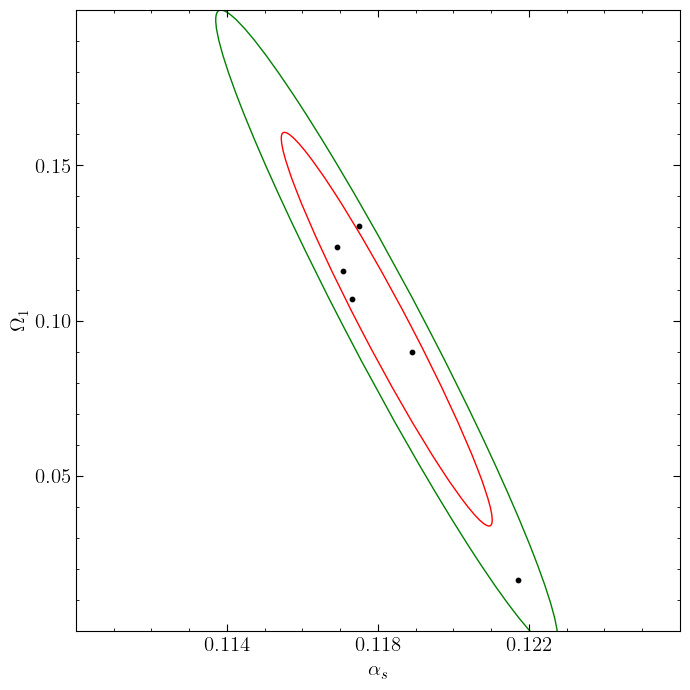

In [168]:
plt.close('all')

fig, ax1 = plt.subplots(1, 1, figsize=(7, 7)) 

sizeOfFont = 15
sizeOfTick = 15

from matplotlib.patches import Ellipse
ellipse_68 = Ellipse(xy=center, width=2*axis_lengths_68[0], height=2*axis_lengths_68[1], angle=angle, edgecolor='red', fc='None')
ellipse_95 = Ellipse(xy=center, width=2*axis_lengths_95[0], height=2*axis_lengths_95[1], angle=angle, edgecolor='green', fc='None')

ax1.add_patch(ellipse_68)
ax1.add_patch(ellipse_95)

#ax1.plot(xlist*180/np.pi, v_2+non_singular_2, label="matched total")
#ax1.errorbar(χ_OPAL, EEC_OPAL, yerr=STAT_OPAL, fmt='o',label="OPAL",color="black", capsize=4,markersize=3)

ax1.set_xlabel(r"\rm $\alpha_s$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\Omega_1$",fontsize=sizeOfFont)
plt.scatter(αs_array, Ω1_array, color="black",s=10)
#ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

#props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,0.2)
plt.xlim(0.110,0.126)

ax1.set_xticks([0.114,0.118,0.122])
ax1.set_yticks([0.05,0.1,0.15])

plt.tight_layout()  
plt.show()